In [1]:
import sympy as sp
sp.init_printing(use_latex='mathjax')

var('e')
R.<z> = QQbar[]

# Convert a complex number in rectangular to a polar tuple
def getPolar(l):
    magnitude = sp.nsimplify(abs(l), constants=[pi])
    angle = sp.nsimplify(arg(l), constants=[pi])
    if (angle < 0):
        angle = angle + 2*pi
    return(magnitude, angle)

# Takes a complex point in polar form and makes it printable
# in exponential notation instead of a tuple
def symbolicPolar(p1):
    return(p1[0] * e^(I * p1[1]))

# Define the function we're working with
ff = z^6 + 1

First up, take a look at what the roots actually are.

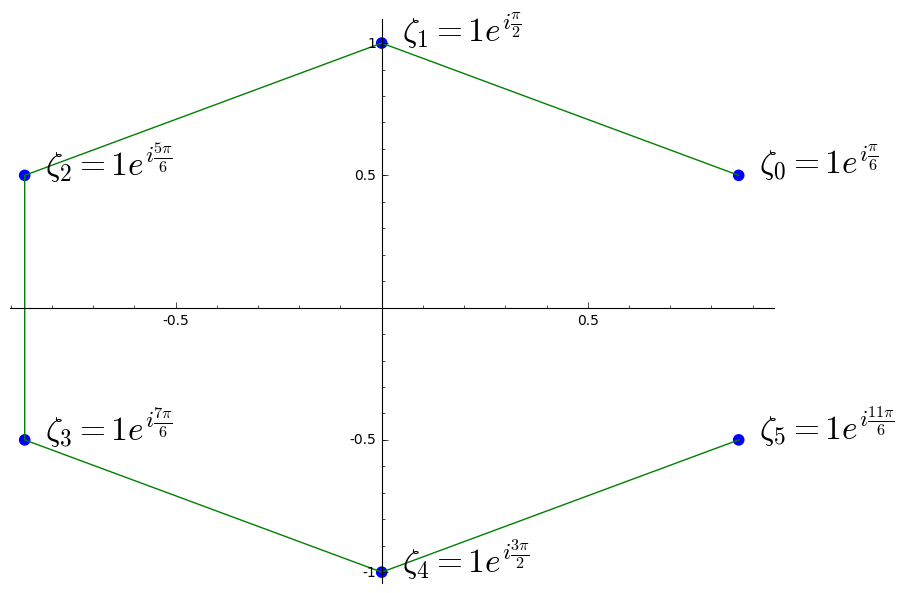

In [4]:
# Extract the roots
pts = ff.roots(multiplicities=False, ring=CC)

# Sort by angle
newpts = []
for p in pts:
    mag = abs(p).round()
    angle = sp.nsimplify(arg(p), constants=[pi])
    if (angle < 0):
        angle = angle + 2*pi
    newpts.append((p, mag, angle))
newpts.sort(key=lambda l: l[2])

# Plot the points, connect them
G = list_plot(map(lambda l: l[0], newpts), size=70, color='blue')
G += list_plot(map(lambda l: l[0], newpts), plotjoined=True, color='green')

# Add labels
for i, p in enumerate(newpts):
    label = '   (%s,%s)' % (p[1],p[2])
    label = '$' + '\zeta_{%s} = %s e^{i %s}' % (i, p[1], sp.latex(p[2])) + '$'
    plotpt = p[0] + CC(.05, .05)
    G += text(label, plotpt, horizontal_alignment='left', color='black', fontsize=24)

G.show()

In [ ]:
pfd = (1/ff).partial_fraction_decomposition()[1]
nums1 = map(lambda l: QQbar(l.numerator()).radical_expression(), pfd)
denoms1 = map(lambda l: QQbar(z - l.denominator()).radical_expression(), pfd)
roots = map(lambda l: (abs(l).round(), sp.nsimplify(arg(l), constants=[pi]) ), denoms1 )

roots2 = map(lambda l: l if l[1] > 0 else (l[0], l[1] + 2*pi), roots)


results = zip(pfd, nums1, denoms1, roots2)
results.sort(key=lambda p: p[3])

nums = map(lambda l: getPolar(QQbar(l.numerator())), pfd)
denoms = map(lambda l: getPolar(QQbar(z - l.denominator())), pfd)

results = zip(nums, denoms)
results.sort(key = lambda l: l[1][1])

nums = map(lambda l: symbolicPolar(l[0]), results)
denoms = map(lambda l: symbolicPolar(l[1]), results)

symbolicFractions = zip(nums, denoms)

symbolicTerms = map(lambda l: l[0] / (z - l[1]), symbolicFractions)

ss = reduce(lambda a,b: a+b, symbolicTerms)
ss

For $k=0,1,2$, computes the products
$$ 
\frac{1}{z^6 + 1} = \frac{1}{\prod_{i=1}^6 (z - \zeta_i)} = \frac{ 1 / \prod_{i\neq k} (z-\zeta_i)}{(z-\zeta_k)^1}
$$

In [29]:
# Define the function
ff = z^6 + 1

# Get all 6 complex roots
pts = ff.roots(multiplicities=False, ring=CC)

# Sort the roots by angle to follow the clockwise convention
# \zeta_0, \zeta_1, ..., \zeta_5
newpts = []
for p in pts:
    mag = abs(p).round()
    angle = sp.nsimplify(arg(p), constants=[pi])
    if (angle < 0):
        angle = angle + 2*pi
    newpts.append((p, mag, angle))
newpts.sort(key=lambda l: l[2])

# Only 3 enclosed singularities at \zeta_0, \zeta_1, \zeta_2
# Print the root and the corresponding product (in polar tuples)
wantpts = map(lambda l: l[0], newpts)

# Compute the product and print
for k, pt in enumerate(wantpts[0:3]):
    display(getPolar(pt))
    otherpts = wantpts[:k] + wantpts[(k + 1):]
    difs = map(lambda l: pt - l, otherpts)
    polar = getPolar(1 / reduce(lambda a,b:a*b, difs) )
    display(polar)
    print('----')

(1, pi/6)

(1/6, 7*pi/6)

----


(1, pi/2)

(1/6, 3*pi/2)

----


(1, 5*pi/6)

(1/6, 11*pi/6)

----


In [26]:
newpts

[(0.866025403784439 + 0.500000000000000*I, 1, pi/6),
 (1.00000000000000*I, 1, pi/2),
 (-0.866025403784439 + 0.500000000000000*I, 1, 5*pi/6),
 (-0.866025403784439 - 0.500000000000000*I, 1, 7*pi/6),
 (-1.00000000000000*I, 1, 3*pi/2),
 (0.866025403784439 - 0.500000000000000*I, 1, 11*pi/6)]

In [18]:
pts[:0]

[]